In [1]:
import sys
sys.path.insert(0, "..")

import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from backbone.resnet import resnet110

split = torch.load("../splits/three_way_seed42.pt", weights_only=False)
split.keys()

dict_keys(['backbone_indices', 'ensemble_indices', 'val_indices', 'seed', 'fracs', 'expert_seeds', 'joint_seeds', 'source', 'test_set', 'created'])

In [2]:
for k, v in split.items():
  print(k, v if not isinstance(v, list) else f"({len(v)}) {v[:5]}")

backbone_indices (25000) [46039, 14461, 45967, 5077, 4398]
ensemble_indices (20000) [38724, 48154, 14513, 27636, 1238]
val_indices (5000) [2936, 41798, 28722, 1979, 42780]
seed 42
fracs {'backbone': 0.5, 'ensemble': 0.4, 'val': 0.1}
expert_seeds (10) [1370068126, 1704034045, 965090079, 528192194, 1975775579]
joint_seeds (5) [476981973, 621715752, 1882162633, 2044397375, 755818579]
source cifar100_train
test_set cifar100_test (official 10k, untouched)
created 2026-07-31


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## Load data

In [4]:
_CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
_CIFAR100_STD = (0.2675, 0.2565, 0.2761)
eval_tf = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize(_CIFAR100_MEAN, _CIFAR100_STD),
])

In [5]:
val_base = datasets.CIFAR100("../data", train=True, transform=eval_tf, download=True)
val_set = Subset(val_base, split["val_indices"])
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

/home/main/Development/research/multi-agent/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Load & run single pre-trained backbone

In [6]:
ckpt = torch.load("../backbone/checkpoints/singles/resnet110_seed1370068126_snap1of1.pt", map_location=device, weights_only=False)
model = resnet110().to(device)
model.load_state_dict(ckpt["state_dict"])
ckpt["metadata"]

{'method': 'snapshot',
 'arch': 'resnet110',
 'depth': 110,
 'seed': 1370068126,
 'split_file': 'splits/three_way_seed42.pt',
 'snapshot': 1,
 'n_snapshots': 1,
 'cycle_epochs': 200,
 'epoch': 200,
 'lr': 0.1,
 'batch_size': 128,
 'val_acc': 0.6406}

In [7]:
model.eval()
correct = total = 0
with torch.inference_mode():
  for x, y in val_loader:
    x, y = x.to(device), y.to(device)
    correct += (model(x).argmax(1) == y).sum().item()
    total += y.size(0)

print(f"val acc: {correct / total:.4f}")

val acc: 0.6410


In [8]:
import matplotlib.pyplot as plt

classes = val_base.classes  # CIFAR-100 label names
mean = torch.tensor(_CIFAR100_MEAN).view(3, 1, 1)
std = torch.tensor(_CIFAR100_STD).view(3, 1, 1)

def show_predictions(images, preds, targets):
  fig, axes = plt.subplots(2, 5, figsize=(12, 5))
  for ax, img, p, t in zip(axes.flat, images, preds, targets):
    ax.imshow((img * std + mean).permute(1, 2, 0).clamp(0, 1))
    ax.set_title(f"{classes[p]}\n({classes[t]})", color="green" if p == t else "red")
    ax.axis("off")
  plt.tight_layout()
  plt.show()

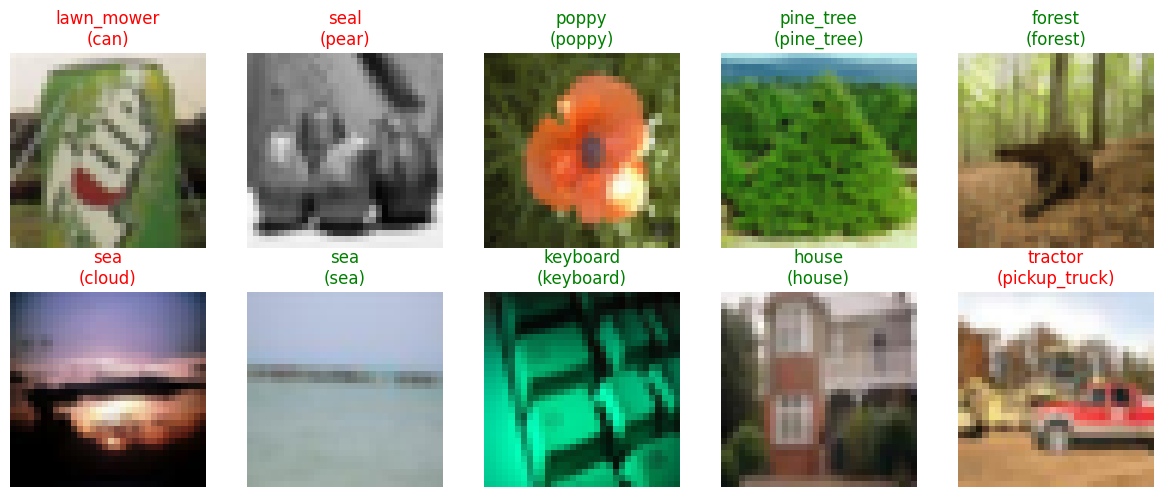

In [9]:
# random sample to print
val_indices = split["val_indices"]
g = torch.Generator().manual_seed(1)
pick = torch.randperm(len(val_indices), generator=g)[:10]
samples = [val_base[val_indices[i]] for i in pick]

x = torch.stack([img for img, _ in samples])
y = torch.tensor([label for _, label in samples])

with torch.inference_mode():
  pred = model(x.to(device)).argmax(1).cpu()

show_predictions(x, pred, y)

## Load & run TarMAC setup

In [10]:
from torchinfo import summary

summary(resnet110(), input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 100]                  --
├─Conv2d: 1-1                            [1, 16, 32, 32]           432
├─BatchNorm2d: 1-2                       [1, 16, 32, 32]           32
├─Sequential: 1-3                        [1, 16, 32, 32]           --
│    └─BasicBlock: 2-1                   [1, 16, 32, 32]           --
│    │    └─Conv2d: 3-1                  [1, 16, 32, 32]           2,304
│    │    └─BatchNorm2d: 3-2             [1, 16, 32, 32]           32
│    │    └─Conv2d: 3-3                  [1, 16, 32, 32]           2,304
│    │    └─BatchNorm2d: 3-4             [1, 16, 32, 32]           32
│    │    └─Sequential: 3-5              [1, 16, 32, 32]           --
│    └─BasicBlock: 2-2                   [1, 16, 32, 32]           --
│    │    └─Conv2d: 3-6                  [1, 16, 32, 32]           2,304
│    │    └─BatchNorm2d: 3-7             [1, 16, 32, 32]           32
│    

In [11]:
from pathlib import Path
import torch.nn as nn

from ensemble.train import TrainConfig, TrainJob, train, make_loaders, build_communicative
from ensemble.eval import evaluate

backbone_paths = [
  Path("../backbone/checkpoints/pool/resnet110_seed1370068126_snap5of5.pt"),
  Path("../backbone/checkpoints/pool/resnet110_seed1704034045_snap5of5.pt"),
  Path("../backbone/checkpoints/pool/resnet110_seed965090079_snap5of5.pt"),
]

In [12]:
cfg = TrainConfig(epochs=50, lr=1e-3, weight_decay=1e-4, seed=0, device=device)
torch.manual_seed(cfg.seed)
torch.cuda.manual_seed_all(cfg.seed)

key_dim, value_dim, k_rounds = 16, 64, 1

# make_loaders trains on ensemble_indices, validates on val_indices (see splits/)
train_loader, comm_val_loader, test_loader = make_loaders(
  Path("../splits/three_way_seed42.pt"), batch_size=128, data_root="../data",
)
orchestrator = build_communicative(
  backbone_paths, early="layer2.0", late="layer3.6",
  key_dim=key_dim, value_dim=value_dim, num_classes=100, device=cfg.device,
)

/home/main/Development/research/multi-agent/.venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [13]:
from aim import Run

run = Run(experiment="probing-tarmac")
run["hparams"] = {
  "backbones": [p.stem for p in backbone_paths],
  "early": "layer2.0", "late": "layer3.6",
  "key_dim": key_dim, "value_dim": value_dim, "k_rounds": k_rounds,
  "epochs": cfg.epochs, "lr": cfg.lr, "weight_decay": cfg.weight_decay,
}
run.hash

'd08db16451c641d4980693e4'

In [14]:
# untrained averaging baselines — computed BEFORE training, while the experts'
# fc heads still hold their pretrained values (training updates them)
@torch.inference_mode()
def logit_average_acc(loader):
  backbones = [s.driver.backbone for s in orchestrator.specialists]
  correct = total = 0
  for x, y in loader:
    x, y = x.to(cfg.device), y.to(cfg.device)
    logits = torch.stack([b(x) for b in backbones]).mean(0)
    correct += (logits.argmax(1) == y).sum().item()
    total += y.size(0)
  return correct / total

logit_avg = logit_average_acc(comm_val_loader)
prob_avg = evaluate(orchestrator, comm_val_loader, device=cfg.device, criterion=nn.NLLLoss(), k_rounds=0)["accuracy"]
print(f"logit_avg (pretrained) val_acc {logit_avg:.4f}")
print(f"prob_avg  (pretrained) val_acc {prob_avg:.4f}")

logit_avg (pretrained) val_acc 0.6988
prob_avg  (pretrained) val_acc 0.6898


In [15]:
# orchestrator outputs log of prob-averaged softmaxes -> NLLLoss, not CE
criterion = nn.NLLLoss()
optimizer = torch.optim.AdamW(orchestrator.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
job = TrainJob(
  model=orchestrator, loader=train_loader, optimizer=optimizer,
  criterion=criterion, config=cfg, run=run, val_loader=comm_val_loader,
)
losses = train(job, k_rounds=k_rounds)

train:   0%|          | 0/7850 [00:00<?, ?it/s]

epoch 1/50  train_accuracy 0.6808  val_accuracy 0.6896  val_loss 1.4213
epoch 2/50  train_accuracy 0.6833  val_accuracy 0.6874  val_loss 1.4067
epoch 3/50  train_accuracy 0.6855  val_accuracy 0.6902  val_loss 1.3925
epoch 4/50  train_accuracy 0.6877  val_accuracy 0.6858  val_loss 1.3745
epoch 5/50  train_accuracy 0.6898  val_accuracy 0.6878  val_loss 1.3580
epoch 6/50  train_accuracy 0.6898  val_accuracy 0.6914  val_loss 1.3506
epoch 7/50  train_accuracy 0.6934  val_accuracy 0.6864  val_loss 1.3400
epoch 8/50  train_accuracy 0.6963  val_accuracy 0.6868  val_loss 1.3343
epoch 9/50  train_accuracy 0.6984  val_accuracy 0.6882  val_loss 1.3296
epoch 10/50  train_accuracy 0.6994  val_accuracy 0.6902  val_loss 1.3384
epoch 11/50  train_accuracy 0.6998  val_accuracy 0.6866  val_loss 1.3254
epoch 12/50  train_accuracy 0.7035  val_accuracy 0.6906  val_loss 1.3206
epoch 13/50  train_accuracy 0.7043  val_accuracy 0.6864  val_loss 1.3203
epoch 14/50  train_accuracy 0.7086  val_accuracy 0.6924  val

In [16]:
# checkpoint like ensemble/train.py: state_dict + metadata
ckpt = Path("../ensemble/checkpoints/probe_communicative.pt")
ckpt.parent.mkdir(parents=True, exist_ok=True)
torch.save({
  "state_dict": orchestrator.state_dict(),
  "metadata": {
    "backbones": [p.stem for p in backbone_paths],
    "early": "layer2.0", "late": "layer3.6",
    "key_dim": key_dim, "value_dim": value_dim, "k_rounds": k_rounds,
    "epochs": cfg.epochs,
  },
}, ckpt)

In [17]:
# reload trained orchestrator instead of retraining (run cells 13-14 first)
orchestrator = build_communicative(
  backbone_paths, early="layer2.0", late="layer3.6",
  key_dim=key_dim, value_dim=value_dim, num_classes=100, device=cfg.device,
)
orchestrator.load_state_dict(
  torch.load("../ensemble/checkpoints/probe_communicative.pt", weights_only=True)["state_dict"]
)

<All keys matched successfully>

In [18]:
# CONTROL: identical training with k_rounds=0 -> no messages, only the fc heads
# fine-tune on ensemble_indices. Communication must beat THIS, not just the
# untrained averages, to prove the messages (not head-tuning) are what helped.
from aim import Run

control_run = Run(experiment="probing-tarmac")
control_run["hparams"] = {
    "backbones": [p.stem for p in backbone_paths],
    "early": "layer2.0", "late": "layer3.6",
    "key_dim": key_dim, "value_dim": value_dim, "k_rounds": 0, "control": True,
    "epochs": cfg.epochs, "lr": cfg.lr, "weight_decay": cfg.weight_decay,
}

control_orch = build_communicative(
  backbone_paths, early="layer2.0", late="layer3.6",
  key_dim=key_dim, value_dim=value_dim, num_classes=100, device=cfg.device,
)
control_opt = torch.optim.AdamW(control_orch.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
control_job = TrainJob(
  model=control_orch, loader=train_loader, optimizer=control_opt,
  criterion=criterion, config=cfg, run=control_run, val_loader=comm_val_loader,
)
control_losses = train(control_job, k_rounds=0)

train:   0%|          | 0/7850 [00:00<?, ?it/s]

epoch 1/50  train_accuracy 0.6836  val_accuracy 0.6898  val_loss 1.4589
epoch 2/50  train_accuracy 0.6862  val_accuracy 0.6860  val_loss 1.4525
epoch 3/50  train_accuracy 0.6874  val_accuracy 0.6848  val_loss 1.4386
epoch 4/50  train_accuracy 0.6867  val_accuracy 0.6856  val_loss 1.4328
epoch 5/50  train_accuracy 0.6909  val_accuracy 0.6846  val_loss 1.4287
epoch 6/50  train_accuracy 0.6915  val_accuracy 0.6846  val_loss 1.4169
epoch 7/50  train_accuracy 0.6947  val_accuracy 0.6860  val_loss 1.4056
epoch 8/50  train_accuracy 0.6950  val_accuracy 0.6864  val_loss 1.3985
epoch 9/50  train_accuracy 0.6968  val_accuracy 0.6878  val_loss 1.3888
epoch 10/50  train_accuracy 0.6980  val_accuracy 0.6876  val_loss 1.3880
epoch 11/50  train_accuracy 0.6992  val_accuracy 0.6868  val_loss 1.3832
epoch 12/50  train_accuracy 0.7007  val_accuracy 0.6900  val_loss 1.3773
epoch 13/50  train_accuracy 0.6996  val_accuracy 0.6878  val_loss 1.3757
epoch 14/50  train_accuracy 0.7034  val_accuracy 0.6868  val

In [19]:
torch.save({
  "state_dict": control_orch.state_dict(),
  "metadata": {"control": True, "k_rounds": 0, "epochs": cfg.epochs},
}, "../ensemble/checkpoints/probe_control.pt")

In [20]:
# trained communicative vs the trained no-message control vs untrained averages
control_acc = evaluate(control_orch, comm_val_loader, device=cfg.device, criterion=criterion, k_rounds=0)["accuracy"]
comm = evaluate(orchestrator, comm_val_loader, device=cfg.device, criterion=criterion, k_rounds=k_rounds)["accuracy"]
for name, acc in [("logit_avg", logit_avg), ("prob_avg", prob_avg),
                  ("control_k0_trained", control_acc), ("communicative", comm)]:
  run.track(acc, name=f"final_{name}_acc")
  print(f"{name:20s} val_acc {acc:.4f}")

logit_avg            val_acc 0.6988
prob_avg             val_acc 0.6898
control_k0_trained   val_acc 0.6796
communicative        val_acc 0.6726


## Linear probes

In [21]:
from contextlib import ExitStack
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np

from backbone.resnet import BasicBlock
from ensemble.communicative.hooks import hook_encoder, HookState

def probe(Xtr, ytr, Xva, yva):
  clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
  clf.fit(Xtr, ytr)
  return clf.score(Xva, yva)

def block_names(backbone):
  return [n for n, m in backbone.named_modules() if isinstance(m, BasicBlock)]

# one forward pass, capture mean-pooled feats at every named layer (paper app. B)
@torch.inference_mode()
def extract_sweep(backbone, loader, names):
  feats = {n: [] for n in names}
  ys, buf, handles = [], {}, []
  for n in names:
    handles.append(backbone.get_submodule(n).register_forward_hook(
      lambda _, __, out, n=n: buf.__setitem__(n, out.mean((2, 3)).cpu())))
  for x, y in loader:
    backbone(x.to(cfg.device))
    for n in names:
      feats[n].append(buf[n])
    ys.append(y)
  for h in handles:
    h.remove()
  return {n: torch.cat(v).numpy() for n, v in feats.items()}, torch.cat(ys).numpy()

# what each expert sends (V) and receives (c) off the bus, plus its late feats (h)
@torch.inference_mode()
def extract_channel(orch, loader):
  specs = orch.specialists
  st = [HookState() for _ in specs]
  h = [[] for _ in specs]; v = [[] for _ in specs]; c = [[] for _ in specs]; ys = []
  with ExitStack() as stack:
    for s, s_ in zip(specs, st):
      stack.enter_context(hook_encoder(s.driver.late, s_))
    for x, y in loader:
      x = x.to(cfg.device)
      Q, K, V = [], [], []
      for i, s in enumerate(specs):
        s.driver.backbone(x)
        h[i].append(s.encoder.reduce(st[i].value).cpu())
        q, k, vv = s.encoder(st[i].value)
        Q.append(q); K.append(k); V.append(vv); v[i].append(vv.cpu())
      agg, _ = orch.bus(torch.stack(Q, 1), torch.stack(K, 1), torch.stack(V, 1))
      for i in range(len(specs)):
        c[i].append(agg[:, i].cpu())
      ys.append(y)
  cat = lambda t: torch.cat(t).numpy()
  return [cat(x) for x in h], [cat(x) for x in v], [cat(x) for x in c], cat(ys)

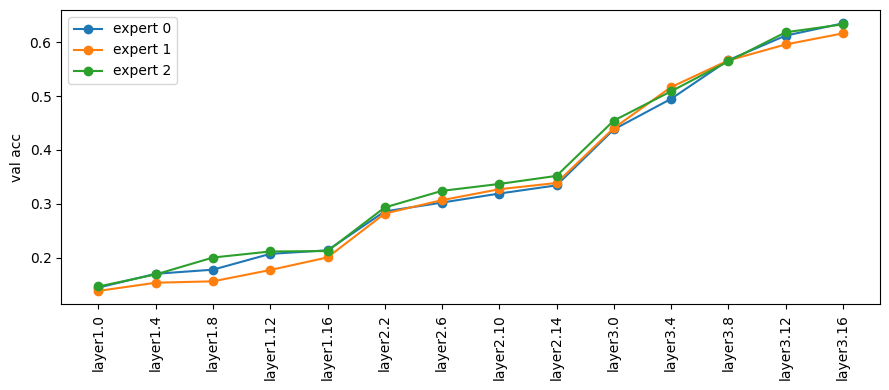

In [22]:
experts = [s.driver.backbone for s in orchestrator.specialists]
names = block_names(experts[0])[::4]   # every 4th block, bump density if needed

import json

sweep = {}
plt.figure(figsize=(9, 4))
for i, bb in enumerate(experts):
  ftr, ytr = extract_sweep(bb, train_loader, names)
  fva, yva = extract_sweep(bb, comm_val_loader, names)
  accs = [probe(ftr[n], ytr, fva[n], yva) for n in names]
  sweep[f"expert{i}"] = dict(zip(names, accs))
  plt.plot(range(len(names)), accs, marker="o", label=f"expert {i}")
json.dump(sweep, open("sweep.json", "w"), indent=2)
plt.xticks(range(len(names)), names, rotation=90)
plt.ylabel("val acc"); plt.legend(); plt.tight_layout(); plt.show()

In [23]:
h, v, c, y = extract_channel(orchestrator, train_loader)
hv, vv, cv, yv = extract_channel(orchestrator, comm_val_loader)

# delivery test: does the received message add anything beyond own feats?
results = {}
singles = []
for i in range(len(orchestrator.specialists)):
  ph = probe(h[i], y, hv[i], yv)
  pc = probe(c[i], y, cv[i], yv)
  phc = probe(np.concatenate([h[i], c[i]], 1), y, np.concatenate([hv[i], cv[i]], 1), yv)
  singles.append(ph)
  results[f"expert{i}"] = {"h": ph, "c": pc, "h+c": phc}
  print(f"expert {i}:  h {ph:.4f}   c {pc:.4f}   h+c {phc:.4f}   gain {phc - ph:+.4f}")

# existence test: marginal info across experts
joint = probe(np.concatenate(h, 1), y, np.concatenate(hv, 1), yv)
print(f"\nbest single h {max(singles):.4f}   concat h {joint:.4f}   headroom {joint - max(singles):+.4f}")
results["concat_h"] = joint
json.dump(results, open("channel.json", "w"), indent=2)

expert 0:  h 0.5342   c 0.5006   h+c 0.5360   gain +0.0018
expert 1:  h 0.5432   c 0.4868   h+c 0.5438   gain +0.0006
expert 2:  h 0.5362   c 0.5232   h+c 0.5362   gain +0.0000

best single h 0.5432   concat h 0.5636   headroom +0.0204
